## Load relevent libraries and adjust visualisation settings

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

sns.set_context('poster')

In [111]:
cancer_data = pd.read_csv("MS4S16_Dataset.csv")

In [112]:
cancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302.0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517.0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903.0,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301.0,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402.0,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [113]:
cancer_data.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
566,926682.0,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
567,926954.0,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
568,927241.0,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
569,92751.0,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039
570,92751.0,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


## Histograms

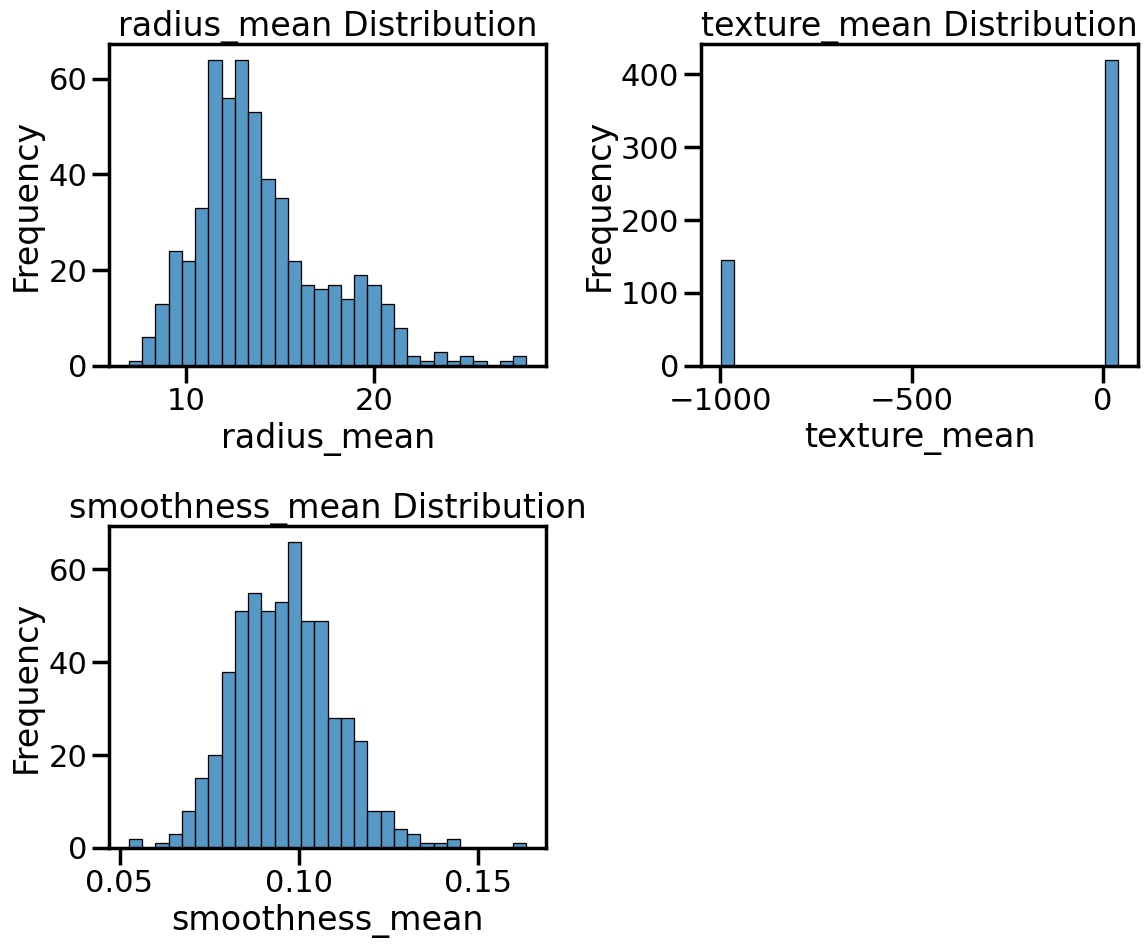

In [114]:
plt.figure(figsize=(12, 10))

features = ['radius_mean', 'texture_mean', 'smoothness_mean']

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(cancer_data[feature], bins=30)
    plt.title(f'{feature} Distribution')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##### radius_mean and smoothness_mean, which revealed normal-looking distributions, followed expected patterns. but texture_mean showed unusual spikes at extreme values(0 or –1000), indicating the presence of placeholder or corrupted values in the raw data.

## Scatterplots

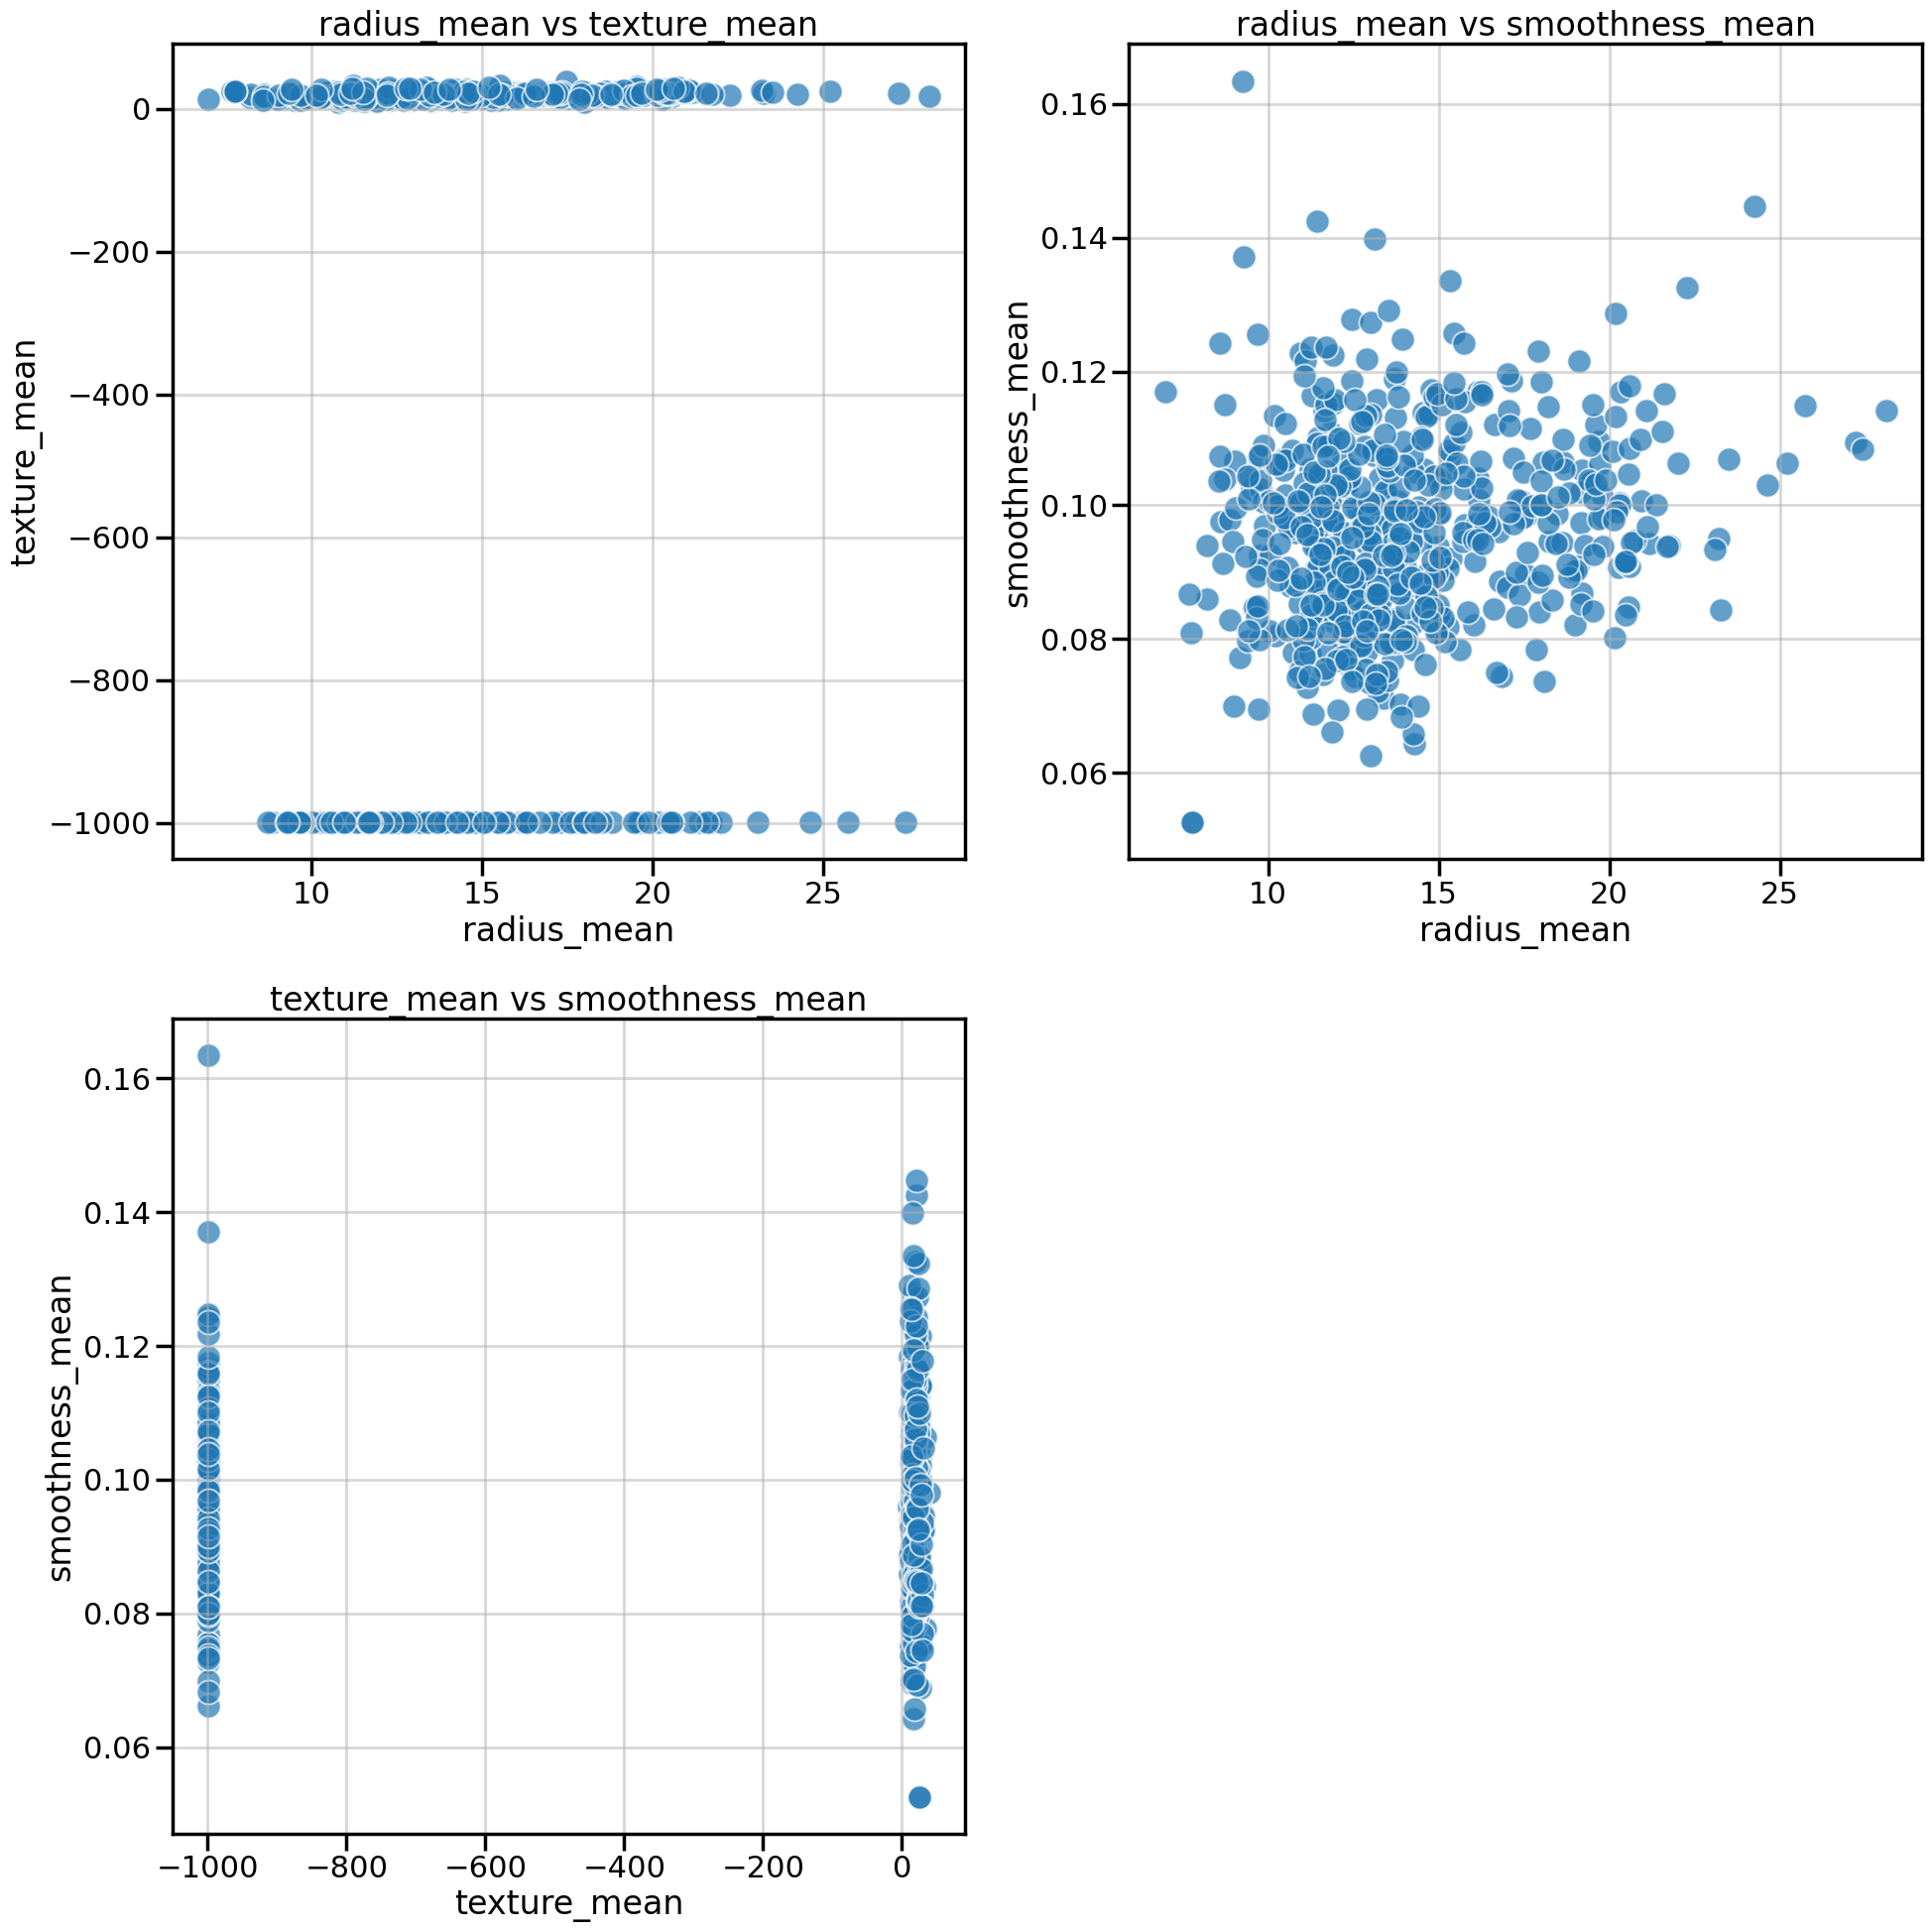

In [115]:
plt.figure(figsize=(20, 20))

colpairs = [
    ('radius_mean', 'texture_mean'),
    ('radius_mean', 'smoothness_mean'),
    ('texture_mean', 'smoothness_mean')
]

for i, (x, y) in enumerate(colpairs, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(
        x=x,
        y=y,
        data=cancer_data,
        s=300,
        alpha=0.7
    )
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

##### Here, Most of the scatterplots reflect inconsistencies. because, raw dataset contains placeholder values(–999) and missing or corrupted entries in some columns.

## Section 1 - Pre processing & EDA

## 1.1 Split into train/test

In [116]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(cancer_data, test_size=0.2, random_state=42)

In [117]:
train_set.shape, test_set.shape

((456, 32), (115, 32))

## 1.2 Clean data

### 1.2.1 handle missing values

In [118]:
train_set.isna().sum()

id                          2
diagnosis                   2
radius_mean                 3
texture_mean                5
perimeter_mean              3
area_mean                   4
smoothness_mean             2
compactness_mean            3
concavity_mean              3
concave points_mean         3
symmetry_mean               2
fractal_dimension_mean      3
radius_se                   3
texture_se                  6
perimeter_se                2
area_se                     3
smoothness_se               5
compactness_se              6
concavity_se                7
concave points_se           7
symmetry_se                 6
fractal_dimension_se        5
radius_worst                9
texture_worst              19
perimeter_worst             5
area_worst                  3
smoothness_worst            7
compactness_worst           2
concavity_worst             2
concave points_worst        4
symmetry_worst              3
fractal_dimension_worst    10
dtype: int64

In [119]:
test_set.isna().sum()

id                         1
diagnosis                  1
radius_mean                2
texture_mean               1
perimeter_mean             1
area_mean                  1
smoothness_mean            1
compactness_mean           1
concavity_mean             1
concave points_mean        5
symmetry_mean              1
fractal_dimension_mean     1
radius_se                  3
texture_se                 2
perimeter_se               1
area_se                    3
smoothness_se              1
compactness_se             1
concavity_se               1
concave points_se          2
symmetry_se                2
fractal_dimension_se       2
radius_worst               4
texture_worst              2
perimeter_worst            1
area_worst                 1
smoothness_worst           2
compactness_worst          2
concavity_worst            1
concave points_worst       2
symmetry_worst             1
fractal_dimension_worst    3
dtype: int64

In [120]:
train_set = train_set.replace(-999, np.nan)

In [121]:
train_set = train_set.dropna()

In [122]:
test_set = test_set.replace(-999, np.nan)

In [123]:
test_set = test_set.dropna()

### 1.2.2 Handle Duplicate rows

In [124]:
train_set = train_set.drop_duplicates()

### 1.2.3 Outlier Detection

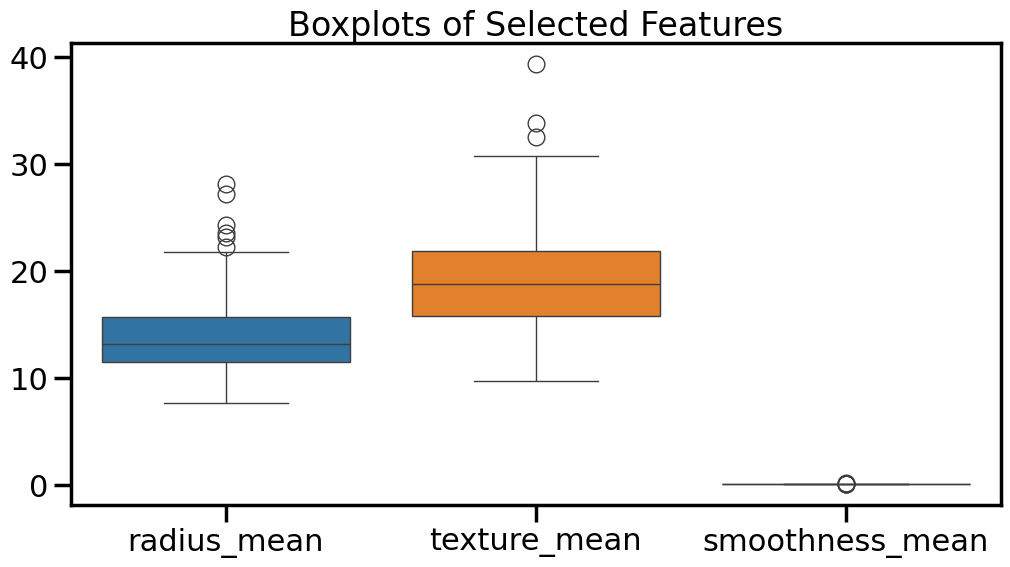

In [125]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train_set[['radius_mean', 'texture_mean', 'smoothness_mean']])
plt.title("Boxplots of Selected Features")
plt.show()

<p>
I checked the outliers of key numerical features using boxplots. radius_mean and texture_mean had a few high-value outliers, while smoothness_mean was tightly grouped. I kept these outliers in the analysis because they looked like normal variations.
</p>

## 1.3 Transform Data

### 1.3.1 Log Transform

In [126]:
train_set['radius_mean_log10'] = np.log10(train_set['radius_mean'])
train_set['texture_mean_log10'] = np.log10(train_set['texture_mean'])
train_set['smoothness_mean_log10'] = np.log10(train_set['smoothness_mean'])

### 1.3.2 Root tranform

In [127]:
train_set['radius_mean_sqrt'] = np.sqrt(train_set['radius_mean'])
train_set['texture_mean_sqrt'] = np.sqrt(train_set['texture_mean'])
train_set['smoothness_mean_sqrt'] = np.sqrt(train_set['smoothness_mean'])

### 1.3.3 Box-Cox transform

In [128]:
from scipy.stats import boxcox

train_set['radius_mean_boxcox'], lambda_radius = boxcox(train_set['radius_mean'])
train_set['texture_mean_boxcox'], lambda_texture = boxcox(train_set['texture_mean'])
train_set['smoothness_mean_boxcox'], lambda_smooth = boxcox(train_set['smoothness_mean'])

lambda_radius, lambda_texture, lambda_smooth

(np.float64(-0.5393442753179931),
 np.float64(0.05040479866463123),
 np.float64(0.2769918054865806))

### 1.3.4 Visualisation of transformation

#### Histograms

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_transformations(train_set, original, log_col, sqrt_col, boxcox_col):
    plt.figure(figsize=(12,8))

    plt.subplot(2,2,1)
    sns.histplot(train_set[original], kde=True)
    plt.title(f"Original: {original}")

    plt.subplot(2,2,2)
    sns.histplot(train_set[log_col], kde=True)
    plt.title(f"Log10 Transform: {log_col}")

    plt.subplot(2,2,3)
    sns.histplot(train_set[sqrt_col], kde=True)
    plt.title(f"Square‑Root Transform: {sqrt_col}")

    plt.subplot(2,2,4)
    sns.histplot(train_set[boxcox_col], kde=True)
    plt.title(f"Box‑Cox Transform: {boxcox_col}")

    plt.tight_layout()
    plt.show()

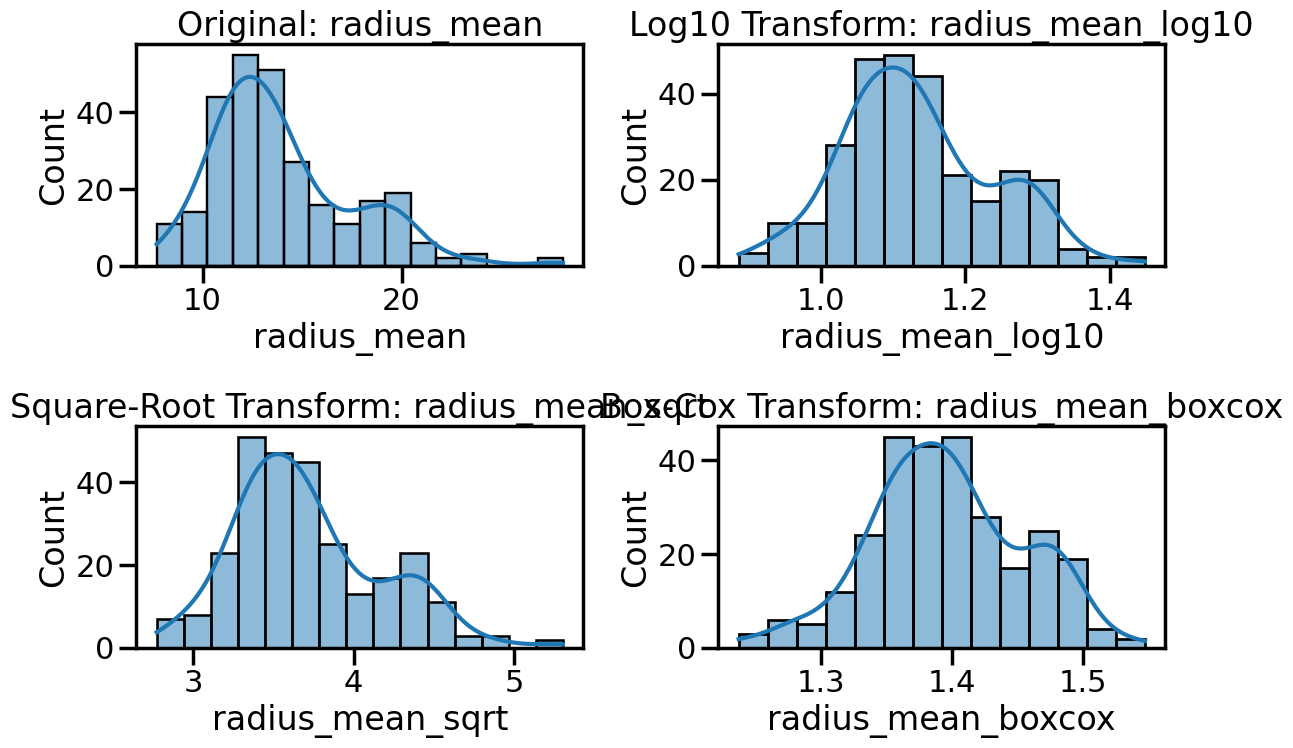

In [130]:
plot_transformations(
    train_set,
    'radius_mean',
    'radius_mean_log10',
    'radius_mean_sqrt',
    'radius_mean_boxcox'
)

<p>
The plots show how different math methods change the radius_mean feature. The original data is right skewed. Most tumours have small radius values, and only a few have very large ones.

The log10 transform reduces the high values and makes the shape more balanced. The square root transform also reduces skew, but not as much as log10.

The Box-Cox transform makes the data look the most normal. It automatically finds the best power for the data, so the distribution becomes more even.

These transforms also help control how spread out the data is. This is better for models that like normal data. It also shows how different methods can change the same feature in different ways.
</p>

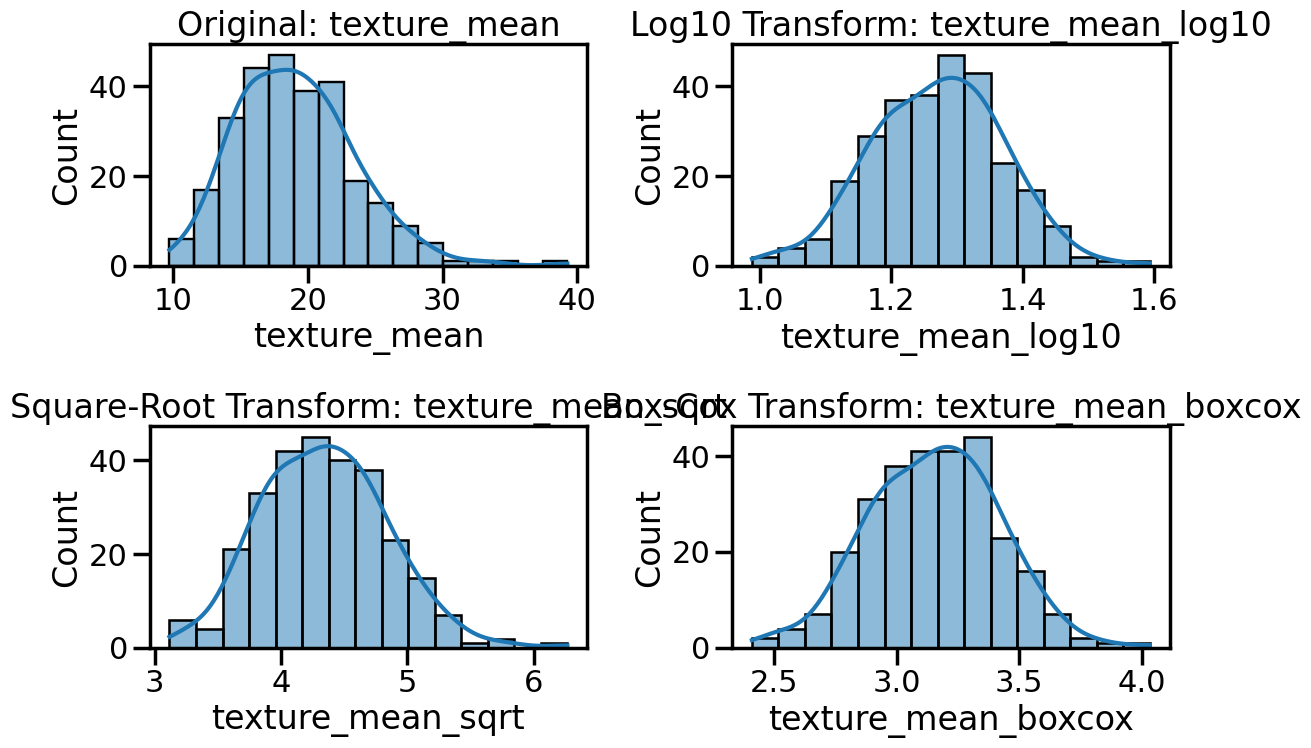

In [131]:
plot_transformations(
    train_set,
    'texture_mean',
    'texture_mean_log10',
    'texture_mean_sqrt',
    'texture_mean_boxcox'
)

<p>
    The original texture_mean feature is right skewed. Most values are low, and only a few are very high. This makes a long tail on the right side.

The log10 transform squashes the high values and makes the shape more balanced. The square root transform also reduces skew, but not as much as log10.

The Box-Cox transform works best. It automatically picks the best power, so the data looks more normal than the others.

These transforms also help control how spread out the data is. This makes the feature easier for models that expect normally distributed input.
</p>

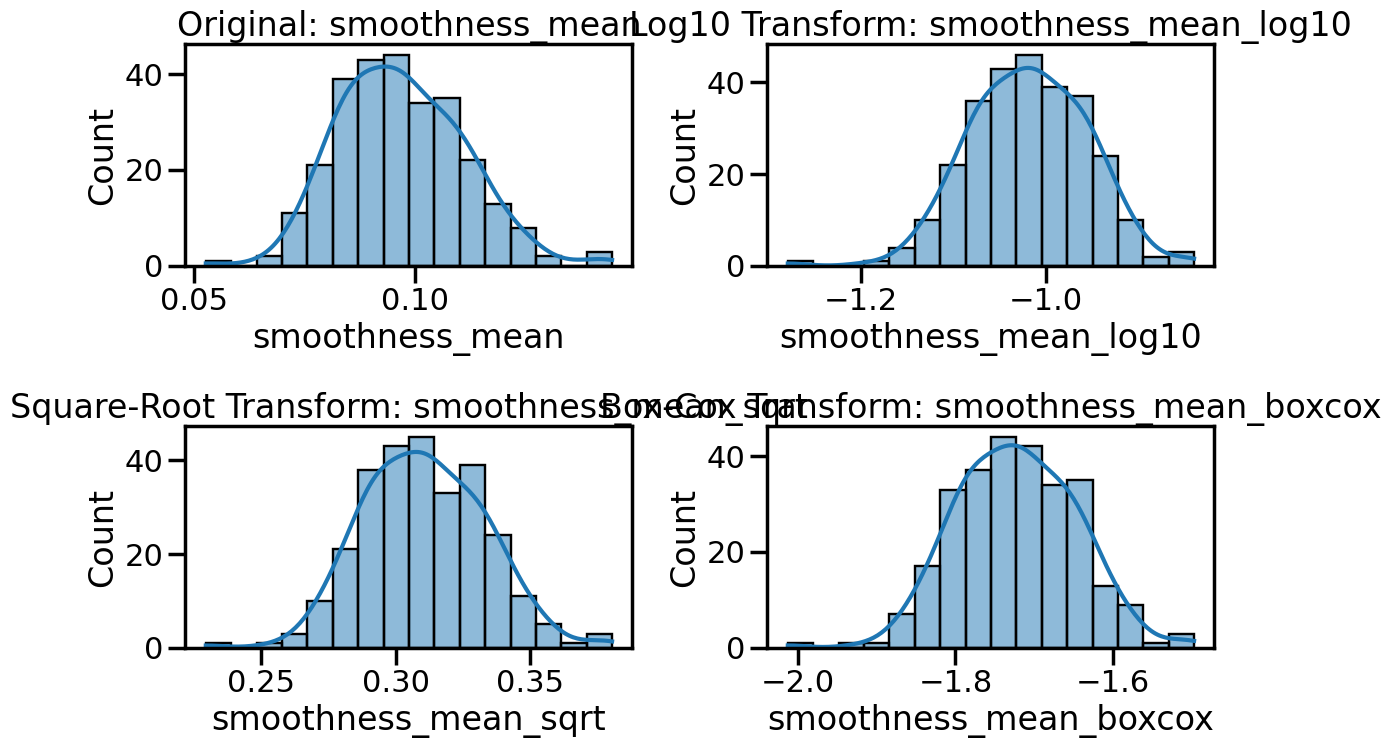

In [132]:
plot_transformations(
    train_set,
    
    'smoothness_mean',
    'smoothness_mean_log10',
    'smoothness_mean_sqrt',
    'smoothness_mean_boxcox'
)

<p>
    The original smoothness_mean feature has values that are very close to each other. Most are around 0.1, and there are only a few small outliers. The data isn’t very skewed.

Because of this, the transforms don’t change the shape much. The log10 transform slightly compresses the values, and the square root transform spreads them a little more evenly.

The Box-Cox transform gives the most balanced shape. It picks the best power automatically, so the data looks more normal.

Overall, these transforms help make the data more stable, but the change is small since smoothness_mean was already pretty balanced.
</p>

## Encode categorical features 

In [133]:
train_set['diagnosis_encoded'] = train_set['diagnosis'].map({'M':1, 'B':0})
test_set['diagnosis_encoded'] = test_set['diagnosis'].map({'M':1, 'B':0})

## 1.4 Handle categorical/ text data

### 1.4.1 Check for categorical columns

In [134]:
categorical_cols = train_set.select_dtypes(include=['object']).columns
categorical_cols

Index(['diagnosis'], dtype='object')

<p>
    The only categorical column is diagnosis. This is the target variable, not an input feature. So the dataset doesn’t have any categorical inputs. The code below just shows how you could handle categorical or text features if they were there.
</p>

### 1.4.2 demonstration- handling a categorical feature

### A. Create a sample categorical column

In [135]:
import numpy as np

np.random.seed(42)
train_set['tumour_location'] = np.random.choice(
    ['left', 'right', 'central'], 
    size=len(train_set)
)

### B. One‑Hot Encoding

In [136]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

tumour_loc_1hot = cat_encoder.fit_transform(train_set[['tumour_location']])
tumour_loc_1hot[:5]

array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

### C. Get the encoded feature names

In [137]:
cat_encoder.get_feature_names_out()

array(['tumour_location_central', 'tumour_location_left',
       'tumour_location_right'], dtype=object)

### D. Convert encoded output to a DataFrame

In [138]:
import pandas as pd

tumour_loc_df = pd.DataFrame(
    tumour_loc_1hot,
    columns=cat_encoder.get_feature_names_out(),
    index=train_set.index
)

tumour_loc_df.head()

,tumour_location_central,tumour_location_left,tumour_location_right
182,1.0,0.0,0.0
63,0.0,1.0,0.0
60,1.0,0.0,0.0
15,1.0,0.0,0.0
333,0.0,1.0,0.0


### E. Combine with numerical features

In [139]:
numerical_features = train_set.drop(columns=['diagnosis', 'tumour_location']).columns

X_processed = pd.concat([train_set[numerical_features], tumour_loc_df], axis=1)
X_processed.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_mean_sqrt,texture_mean_sqrt,smoothness_mean_sqrt,radius_mean_boxcox,texture_mean_boxcox,smoothness_mean_boxcox,diagnosis_encoded,tumour_location_central,tumour_location_left,tumour_location_right
182,873701.0,15.700,20.31,101.20,766.6,0.09597,0.08799,0.065930,0.051890,0.1618,...,3.962323,4.506662,0.309790,1.434216,3.251631,-1.723992,1,1.0,0.0,0.0
63,859196.0,9.173,13.86,59.20,260.9,0.07721,0.08751,0.059880,0.021800,0.2341,...,3.028696,3.722902,0.277867,1.293044,2.811154,-1.834277,0,0.0,1.0,0.0
60,858970.0,10.170,14.88,64.55,311.9,0.11340,0.08061,0.010840,0.012900,0.2743,...,3.189044,3.857460,0.336749,1.323413,2.892372,-1.634753,0,1.0,0.0,0.0
15,84799002.0,14.540,27.54,96.73,658.8,0.11390,0.15950,0.163900,0.073640,0.2303,...,3.813135,5.247857,0.337491,1.416469,3.608803,-1.632344,1,1.0,0.0,0.0
333,897137.0,11.250,14.78,71.38,390.0,0.08306,0.04458,0.000974,0.002941,0.1773,...,3.354102,3.844477,0.288201,1.351528,2.884647,-1.797984,0,0.0,1.0,0.0


## 1.5 Feature Scaling

### 1.5.1 Min‑Max Scaling (Normalisation)

In [140]:
from sklearn.preprocessing import MinMaxScaler

scaler_radius = MinMaxScaler()
scaler_texture = MinMaxScaler()
scaler_smoothness = MinMaxScaler()

train_set['radius_mean_norm'] = scaler_radius.fit_transform(train_set[['radius_mean']])
train_set['texture_mean_norm'] = scaler_texture.fit_transform(train_set[['texture_mean']])
train_set['smoothness_mean_norm'] = scaler_smoothness.fit_transform(train_set[['smoothness_mean']])

### 1.5.2 Standardisation (Z‑Score Scaling)

In [141]:
from sklearn.preprocessing import StandardScaler

scaler_radius = StandardScaler()
scaler_texture = StandardScaler()
scaler_smoothness = StandardScaler()

train_set['radius_mean_std'] = scaler_radius.fit_transform(train_set[['radius_mean']])
train_set['texture_mean_std'] = scaler_texture.fit_transform(train_set[['texture_mean']])
train_set['smoothness_mean_std'] = scaler_smoothness.fit_transform(train_set[['smoothness_mean']])

In [142]:
train_set[['radius_mean', 'radius_mean_norm', 'radius_mean_std']].head()

,radius_mean,radius_mean_norm,radius_mean_std
182,15.700,0.392233,0.485018
63,9.173,0.072579,-1.360027
60,10.170,0.121407,-1.078196
15,14.540,0.335423,0.157110
333,11.250,0.174298,-0.772903


### 1.5.3 Visualisation of feature scaling

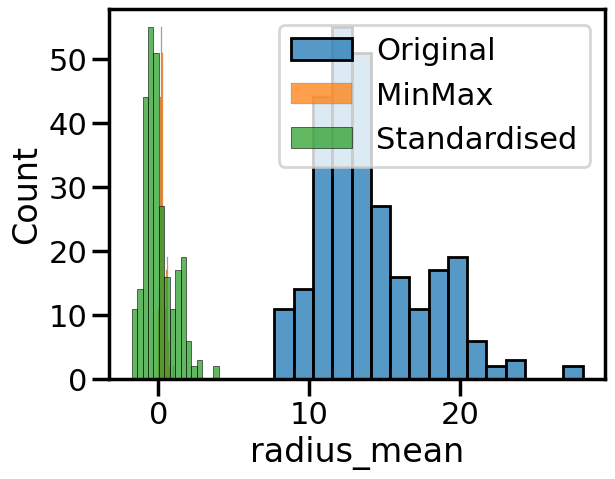

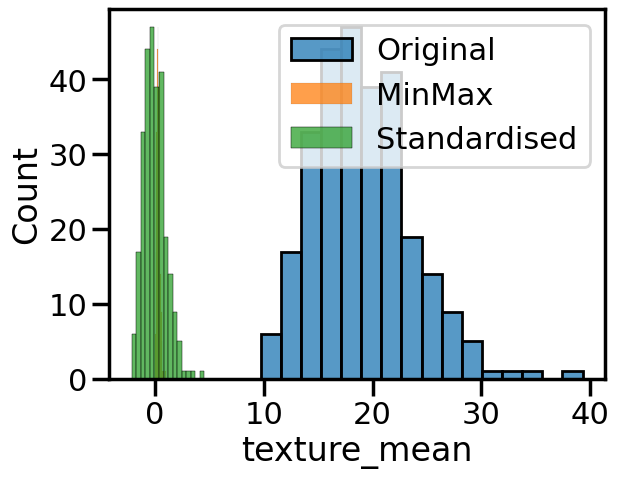

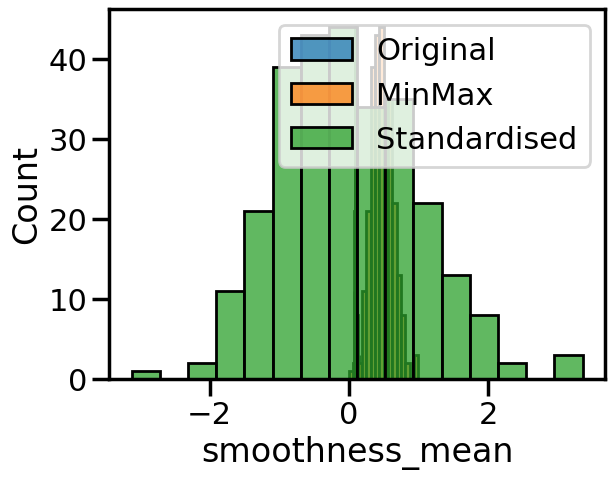

In [143]:
sns.histplot(train_set['radius_mean'], label='Original')
sns.histplot(train_set['radius_mean_norm'], label='MinMax')
sns.histplot(train_set['radius_mean_std'], label='Standardised')
plt.legend()
plt.show()

sns.histplot(train_set['texture_mean'], label='Original')
sns.histplot(train_set['texture_mean_norm'], label='MinMax')
sns.histplot(train_set['texture_mean_std'], label='Standardised')
plt.legend()
plt.show()

sns.histplot(train_set['smoothness_mean'], label='Original')
sns.histplot(train_set['smoothness_mean_norm'], label='MinMax')
sns.histplot(train_set['smoothness_mean_std'], label='Standardised')
plt.legend()
plt.show()

<p>
    The histograms compare the original, MinMax-scaled, and standardised versions of the features. The original features keep their normal ranges and centres.

MinMax scaling squeezes the values into 0–1 but keeps the shape. Standardisation changes the values so the mean is 0 and the standard deviation is 1, centring the data around zero.

The numbers change, but the shapes stay the same. This shows that scaling only affects the size and spread, not the basic pattern of the features.
</p>

## 1.6 feature engineering

### 1.6.1 feature creation

In [144]:
train_set['radius_texture_ratio'] = train_set['radius_mean'] / train_set['texture_mean']
train_set['radius_smoothness_product'] = train_set['radius_mean'] * train_set['smoothness_mean']
train_set['texture_smoothness_diff'] = train_set['texture_mean'] - train_set['smoothness_mean']

test_set['radius_texture_ratio'] = test_set['radius_mean'] / test_set['texture_mean']
test_set['radius_smoothness_product'] = test_set['radius_mean'] * test_set['smoothness_mean']
test_set['texture_smoothness_diff'] = test_set['texture_mean'] - test_set['smoothness_mean']

### 1.6.2 Feature Extraction

In [145]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(train_set[['radius_mean', 'texture_mean', 'smoothness_mean']])

train_set['PC1'] = pca_components[:, 0]
train_set['PC2'] = pca_components[:, 1]

test_set[['PC1', 'PC2']] = pca.transform(test_set[['radius_mean', 'texture_mean', 'smoothness_mean']])

### 1.6.3 Feature Selection

##### Here we can find the most important features to predict the target variable. I used the correlation method to select the features.

In [146]:
import pandas as pd
import numpy as np

predictors = train_set[
    [
        'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
        'smoothness_mean', 'compactness_mean', 'concavity_mean',
        'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean'
    ]
]

threshold = 0.75
cols = predictors.columns.tolist()

while True:
    corr_matrix = predictors[cols].corr().abs()

    np.fill_diagonal(corr_matrix.values, 0)

    max_corr = corr_matrix.max().max()

    # Stop if below threshold
    if max_corr < threshold:
        break

    A, B = np.where(corr_matrix == max_corr)
    A = cols[A[0]]
    B = cols[B[0]]

    A_avg = corr_matrix[A].mean()
    B_avg = corr_matrix[B].mean()

    if A_avg > B_avg:
        print(f"Removing {A} (avg corr = {A_avg:.2f})")
        cols.remove(A)
    else:
        print(f"Removing {B} (avg corr = {B_avg:.2f})")
        cols.remove(B)

print("Selected features:", cols)

Removing perimeter_mean (avg corr = 0.50)
Removing radius_mean (avg corr = 0.43)
Removing concavity_mean (avg corr = 0.50)
Removing compactness_mean (avg corr = 0.44)
Removing concave points_mean (avg corr = 0.35)
Selected features: ['texture_mean', 'area_mean', 'smoothness_mean', 'symmetry_mean', 'fractal_dimension_mean']


<p>
    The feature selection removed predictors that were more correlated with others. These features didn’t add much unique information. Features like perimeter_mean, radius_mean, concavity_mean, compactness_mean, and concave points_mean were left out because their correlations were between 0.35 and 0.50, showing some overlap with other features.

The features that were kept—texture_mean, area_mean, smoothness_mean, symmetry_mean, and fractal_dimension_mean—had lower correlations. This means they give more independent information. These are better for modelling because they reduce multicollinearity and make the model more stable.
</p>

## 1.7 Looking at the Relationships Between Variables

<p>
    Here I show how the variables relate to each other using correlations, pairwise plots, scatterplots, PCA, and distributions grouped by diagnosis.
</p>

### 1.7.1 Correlation matrix

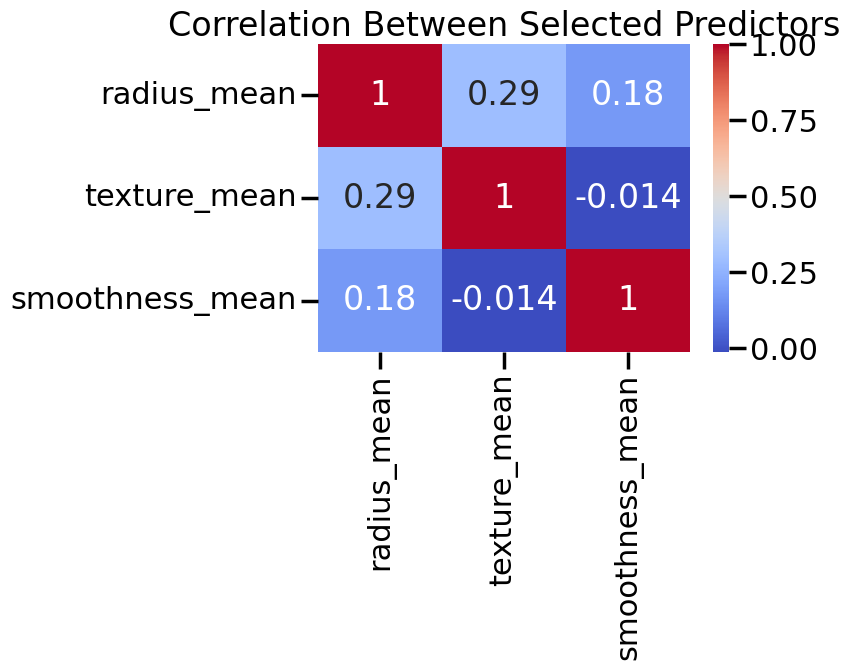

In [147]:
cols = ['radius_mean', 'texture_mean', 'smoothness_mean']
plt.figure(figsize=(6, 4))
sns.heatmap(train_set[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Selected Predictors")
plt.show()

<p>
    The correlation matrix shows the three predictors are mostly independent. radius_mean has a small positive correlation with texture_mean (0.29) and an even weaker one with smoothness_mean (0.18). Texture_mean and smoothness_mean are almost uncorrelated (–0.014), so they don’t really have a linear relationship. Overall, this means each feature can add its own information, and the risk of multicollinearity is low.
</p>

### 1.7.2 Pairwise Relationships

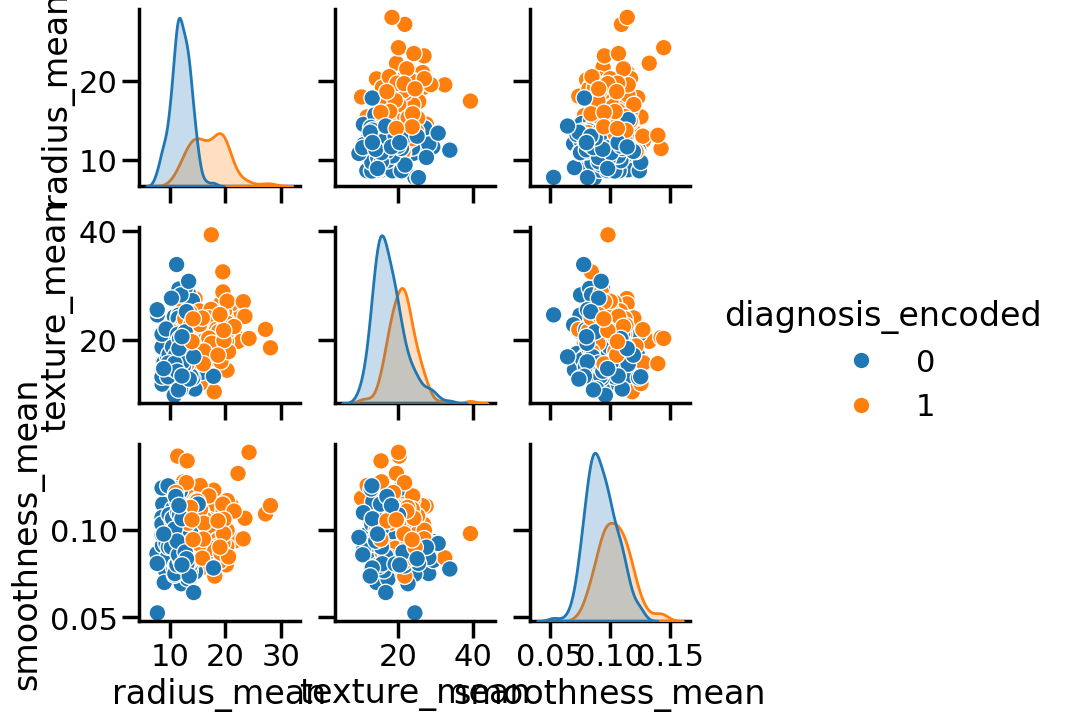

In [148]:
sns.pairplot(train_set[['radius_mean', 'texture_mean', 'smoothness_mean', 'diagnosis_encoded']],
             hue='diagnosis_encoded')
plt.show()

<p>
    The pairplot shows how the three predictors—radius_mean, texture_mean, and smoothness_mean—relate to each other. The points are coloured by the diagnosis label.

The diagonal plots show each feature’s distribution. The scatterplots off the diagonal show how the features pair up. They confirm that the features only have weak linear relationships, which matches the correlation matrix.

The colours show that malignant and benign cases often appear in different areas, especially for radius_mean. This means the features can still help classify cases, even if they aren’t strongly correlated with each other.
</p>

### 1.7.3 Relationship With Target Variable

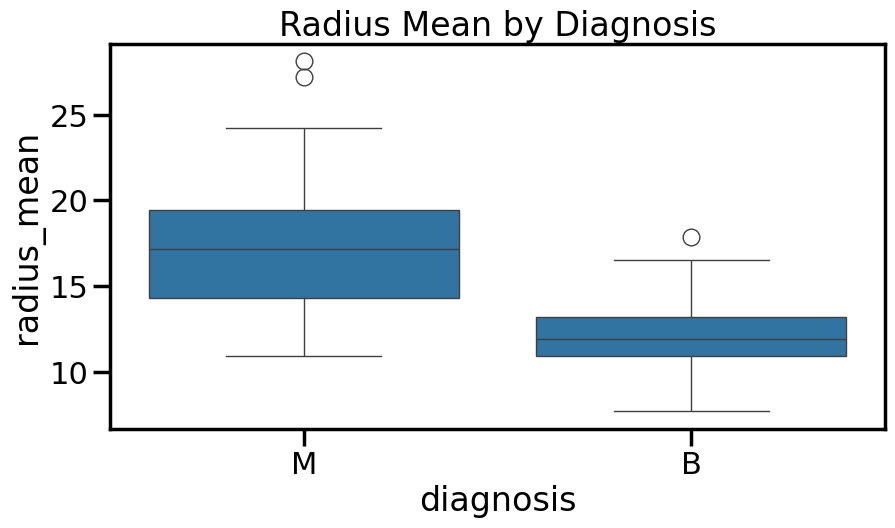

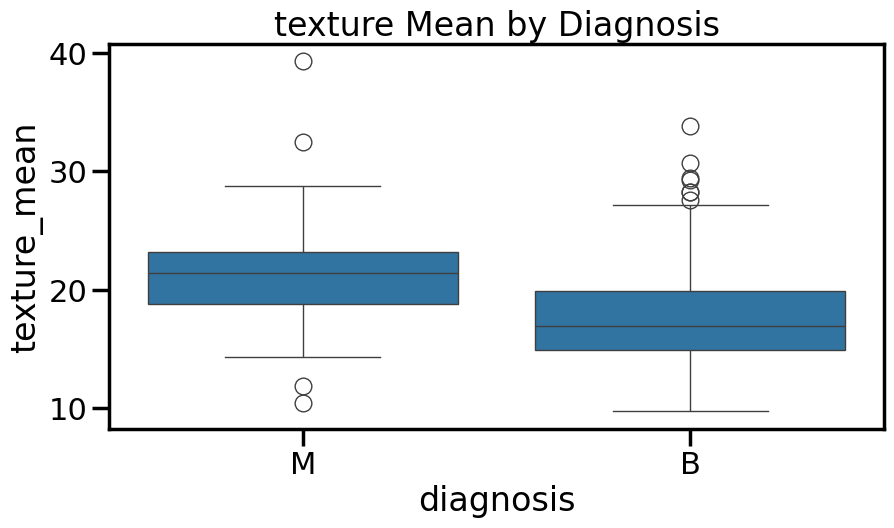

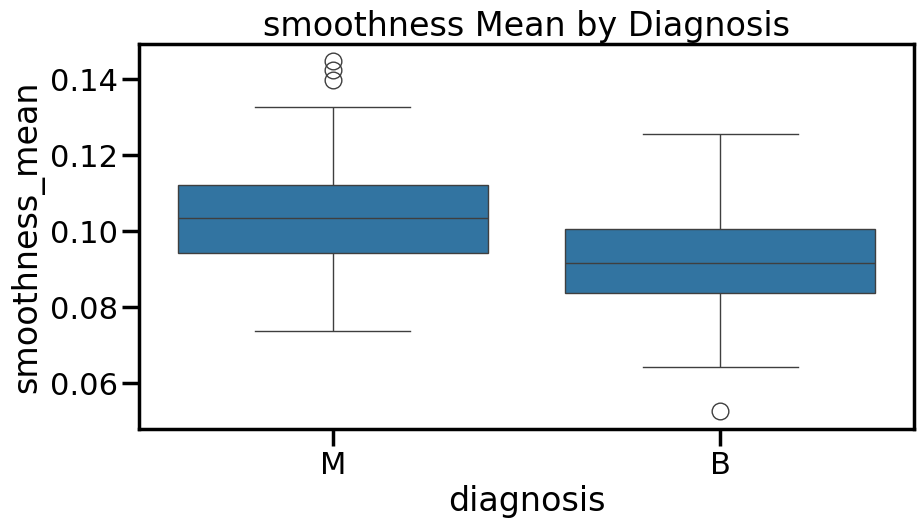

In [149]:
plt.figure(figsize=(10,5))
sns.boxplot(x='diagnosis', y='radius_mean', data=train_set)
plt.title("Radius Mean by Diagnosis")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='diagnosis', y='texture_mean', data=train_set)
plt.title("texture Mean by Diagnosis")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='diagnosis', y='smoothness_mean', data=train_set)
plt.title("smoothness Mean by Diagnosis")
plt.show()

<p>
    The boxplots compare radius_mean, texture_mean, and smoothness_mean for malignant (M) and benign (B) tumours. For all three features, malignant tumours have higher medians and wider spreads, showing more variation. Radius_mean and texture_mean show the clearest differences, with malignant cases usually having bigger values. Smoothness_mean also differs, but the gap is smaller.

There are a few outliers in each plot, which is normal in medical data. Overall, these plots show that malignant tumours tend to be bigger and more variable, so these features are useful for classification.
</p>

### 1.7.4 PCA Component Relationships

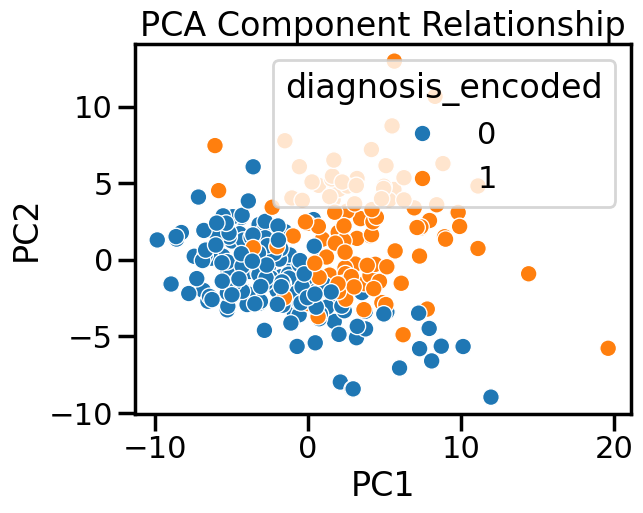

In [150]:
sns.scatterplot(x='PC1', y='PC2', hue='diagnosis_encoded', data=train_set)
plt.title("PCA Component Relationship")
plt.show()

<p>
    The PCA scatter plot shows how the data spreads across the first two components, PC1 and PC2. The two diagnosis groups form partly separate clusters. Malignant and benign cases are in different areas in the PCA space. This means the features have patterns that PCA can pick up, and the first two components keep enough information to see the classes apart.

The clusters do overlap a little, but the separation shows the features still have useful information for classification.
</p>

# Section 2 - Unsupervised Machine learning

## 2.1 Clustering techques

### 2.1.1 K‑Means Clustering

In [157]:
from sklearn.cluster import KMeans

X_unsupervised = train_set[['radius_mean', 'texture_mean', 'smoothness_mean']]

kmeans = KMeans(n_clusters=2, random_state=42)
train_set['cluster'] = kmeans.fit_predict(X_unsupervised)

kmeans_labels = train_set['cluster']

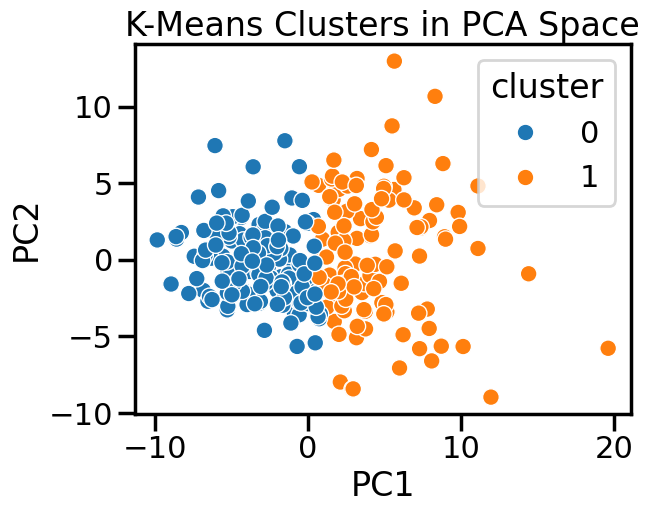

In [158]:
# Visualising Cluster
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    palette='tab10',
    data=train_set
)
plt.title("K-Means Clusters in PCA Space")
plt.show()

<p>
    K-Means clustering is shown in PCA space using the first two components. The scatterplot shows two fairly separate groups, which suggests the data naturally forms two clusters. This matches the diagnosis labels (benign and malignant), even though the clustering didn’t use the labels. The separation along PC1 shows that the main differences in the data line up with the benign–malignant distinction.
</p>

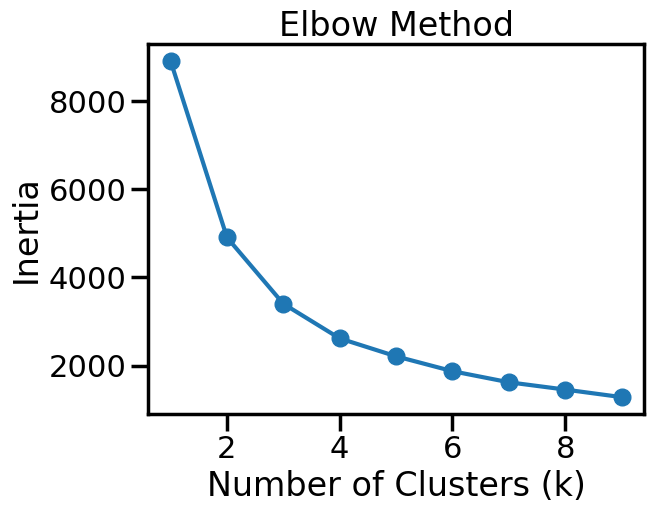

In [159]:
# Elbow Method
inertia_values = []
K = range(1, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_unsupervised)
    inertia_values.append(km.inertia_)

plt.plot(K, inertia_values, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

<p>
    The Elbow Method plot shows how the variation within clusters (inertia) changes as we increase the number of clusters. There is a big drop from k = 1 to k = 3, then the curve flattens out. This means adding more clusters after k = 3 only gives small improvements. The “elbow” at k = 3 suggests that three clusters give the best balance between simplicity and how well the clusters fit the data.
</p>

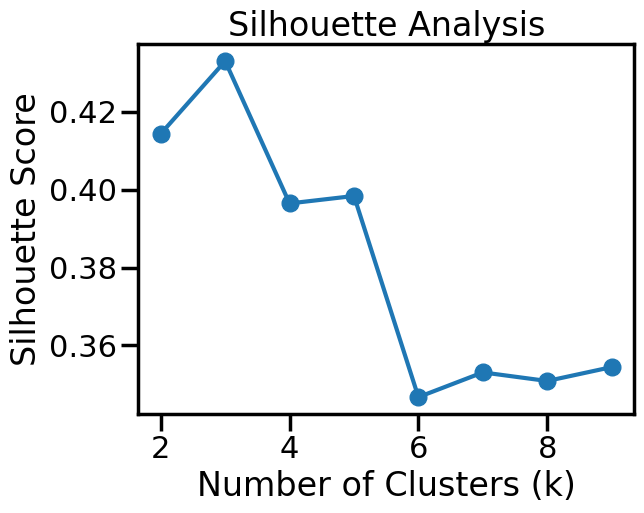

In [160]:
# Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_unsupervised)
    silhouette_scores.append(silhouette_score(X_unsupervised, labels))

plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

<p>
    The Silhouette Analysis plot shows how well the clusters are separated for different k values. The silhouette score is highest at k = 3, which means three clusters make the clearest groups. When k goes above 3, the score drops and the clusters become less distinct. This supports that three clusters are the best choice for this dataset.
</p>

### 2.1.2 Hierarchical Clustering (Agglomerative Clustering)

In [162]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(linkage='ward', n_clusters=2)
agg_labels = agg_clustering.fit_predict(X_unsupervised)
train_set['agg_cluster'] = agg_labels

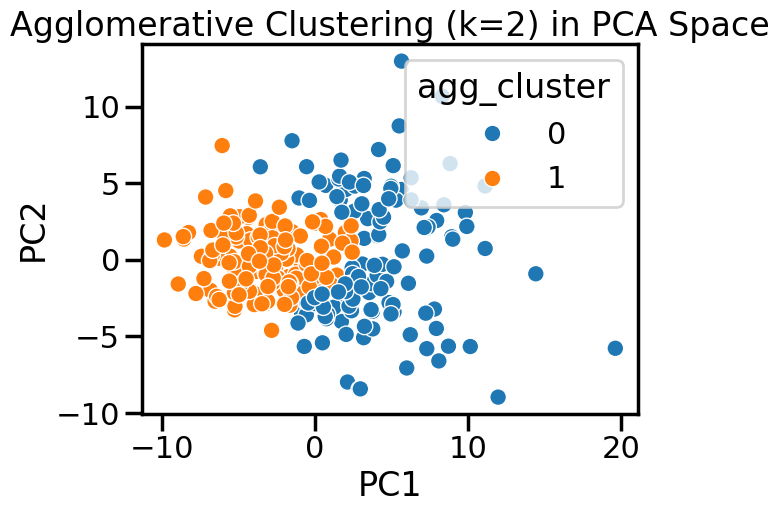

In [163]:
# Visualising Agglomerative Clustering

sns.scatterplot(
    x='PC1', y='PC2',
    hue='agg_cluster',
    palette='tab10',
    data=train_set
)
plt.title("Agglomerative Clustering (k=2) in PCA Space")
plt.show()

<p>
    The agglomerative clustering plot for k = 2 shows two clear groups in PCA space. Even though k = 3 was best according to the Elbow Method and Silhouette Analysis, showing k = 2 helps see the bigger picture of the data. The clusters are fairly well separated, which confirms the dataset has real patterns and structure.
</p>

In [164]:
pd.crosstab(train_set['agg_cluster'], train_set['diagnosis'])

diagnosis,B,M
agg_cluster,,
0,41,83
1,127,27


<p>
    A cross-tab between the hierarchical clustering labels and the diagnosis shows a clear link. Cluster 0 had mostly malignant cases (83 malignant and 41 benign). Cluster 1 had mostly benign cases (127 benign and 27 malignant). There is some overlap, but most samples ended up in the right group. This shows that hierarchical clustering could capture the natural two-group structure, even without using the labels.
</p>

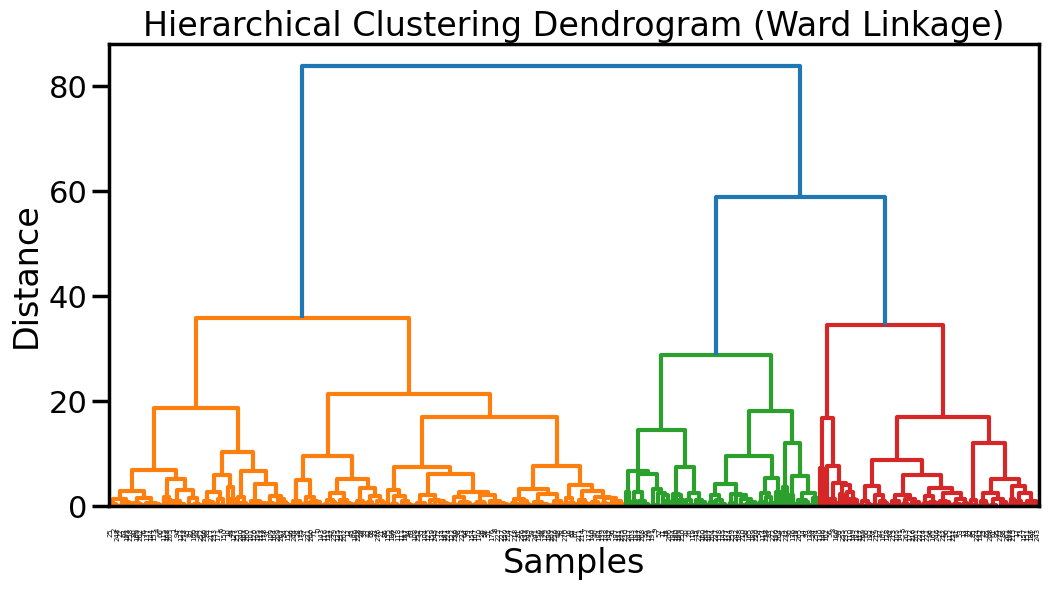

In [165]:
# Dendrogram (SciPy Linkage)

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

X_unsupervised = train_set[['radius_mean', 'texture_mean', 'smoothness_mean']]

Z = linkage(X_unsupervised, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

<p>
    The dendrogram shows how samples are grouped using hierarchical clustering with Ward linkage. At small distances, single samples join to make small clusters. As the distance grows, these small clusters merge into bigger ones. The branching pattern shows clear separation between main clusters, which means the data has real structure.

The height where branches join shows how similar or different the clusters are. Taller joins mean the clusters are more different. Overall, the dendrogram gives a clear view of the grouping and shows that natural clusters exist in the dataset.
</p>

### 2.1.3 DBSCAN-Density‑based clustering algorithm

In [168]:
from sklearn.cluster import DBSCAN

X_unsupervised = train_set[['radius_mean', 'texture_mean', 'smoothness_mean']]

dbscan = DBSCAN(eps=0.25, min_samples=10)
dbscan.fit(X_unsupervised)

dbscan_labels = dbscan.labels_

train_set['dbscan_cluster'] = dbscan_labels

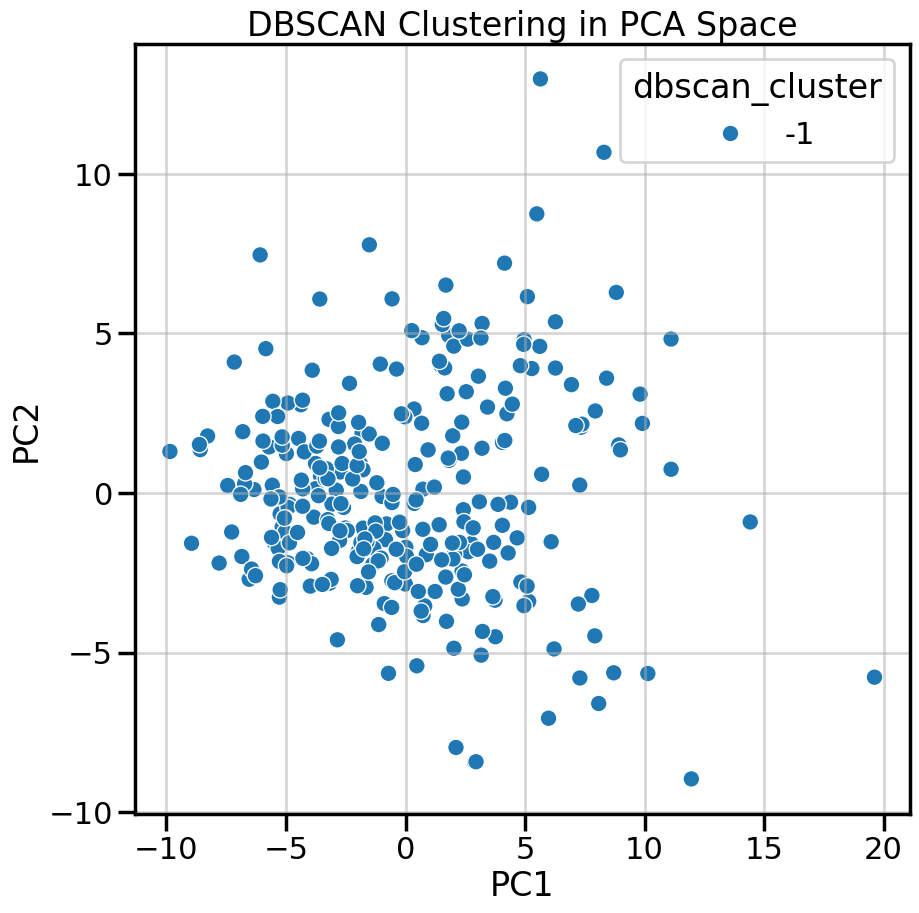

In [169]:
# visualize DBScan

plt.figure(figsize=(10,10))
sns.set_context('poster')

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='dbscan_cluster',
    palette='tab10',
    data=train_set
)

plt.title("DBSCAN Clustering in PCA Space")
plt.grid(alpha=0.5)
plt.show()

<p>
    DBSCAN didn’t find any clear clusters. It put all the samples in the noise group (cluster −1). This means the data isn’t dense enough for DBSCAN to make clusters with these settings. This matches the PCA plot, where the groups overlap. It shows that density-based clustering doesn’t work well for this dataset.
</p>

## 2.2 Dimensionally reduction-PCA 

In [172]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select features for PCA
X_unsupervised = train_set[['radius_mean', 'texture_mean', 'smoothness_mean']]

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

# Apply PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

# Store components
train_set['PC1'] = pca_components[:, 0]
train_set['PC2'] = pca_components[:, 1]

# Explained variance
pca.explained_variance_ratio_

array([0.44471188, 0.33738206])

<p>
    The first two principal components explained 78.21% of the total variance (PC1 = 44.47% and PC2 = 33.74%). This means most of the information from the original features was kept even after reducing the dimensions.
</p>

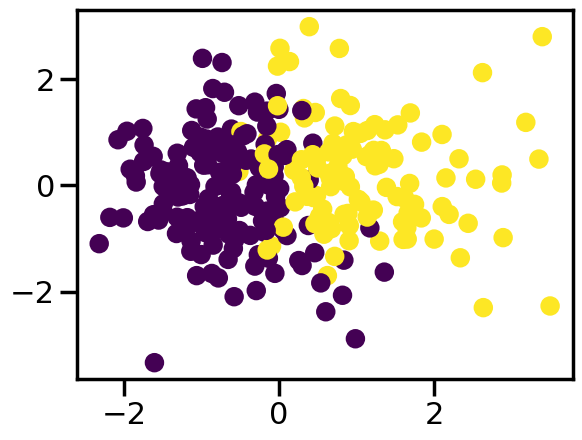

In [173]:
plt.scatter(train_set['PC1'], train_set['PC2'], c=train_set['diagnosis_encoded'])

<p>
    A scatter plot of PC1 versus PC2 was made, with points coloured by diagnosis. The two classes form fairly separate clusters in PCA space. This shows the features have useful patterns that PCA picked up. There is some overlap, but the separation shows the reduced components still have useful information for classification.
</p>

## 2.3 Evaluate the Different Clustering Algorithms

In [175]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X_unsupervised = train_set[['radius_mean', 'texture_mean', 'smoothness_mean']]

# K-Means metrics
print("K-Means Silhouette:", silhouette_score(X_unsupervised, kmeans_labels))
print("K-Means DB Index:", davies_bouldin_score(X_unsupervised, kmeans_labels))
print("K-Means CH Index:", calinski_harabasz_score(X_unsupervised, kmeans_labels))

# Hierarchical metrics
print("Hierarchical Silhouette:", silhouette_score(X_unsupervised, agg_labels))
print("Hierarchical DB Index:", davies_bouldin_score(X_unsupervised, agg_labels))
print("Hierarchical CH Index:", calinski_harabasz_score(X_unsupervised, agg_labels))

# DBSCAN metrics (only if >1 cluster)
if len(set(dbscan_labels)) > 1:
    print("DBSCAN Silhouette:", silhouette_score(X_unsupervised, dbscan_labels))
    print("DBSCAN DB Index:", davies_bouldin_score(X_unsupervised, dbscan_labels))
else:
    print("DBSCAN produced only one cluster — metrics not applicable.")

K-Means Silhouette: 0.4143135194943948
K-Means DB Index: 0.9704421139035752
K-Means CH Index: 225.20474458587282
Hierarchical Silhouette: 0.36348853042607343
Hierarchical DB Index: 1.0836786005270338
Hierarchical CH Index: 179.75341245238948
DBSCAN produced only one cluster — metrics not applicable.


<p>
    K-Means gave the best clustering results. It had a silhouette score of 0.4143, a Davies–Bouldin index of 0.9704, and a Calinski–Harabasz index of 225.20, showing compact and fairly well-separated clusters. Hierarchical clustering didn’t do as well, with lower silhouette and CH scores and a higher DB index. DBSCAN failed completely, putting all samples in the noise class, so its metrics don’t count. Overall, K-Means was the best clustering method for this dataset.
</p>

# Section 3 : Supervised Machine learning

## 3.1 Prepare the data

In [179]:
train_set['diagnosis_encoded'] = train_set['diagnosis'].map({'B':0, 'M':1})

In [180]:
features = ['radius_mean', 'texture_mean', 'smoothness_mean',
            'area_mean', 'concavity_mean', 'compactness_mean']
X = train_set[features]
y = train_set['diagnosis_encoded']

## 3.2 Train-test split

In [181]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 3.3 Scaling (MinMaxScaler)

In [182]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.4 Train Multiple Classification Models

### 3.4.1 Logistic Regression

In [184]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 3.4.2 K‑Nearest Neighbours

In [185]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 3.4.3 Decision Tree

In [186]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)   # trees do NOT need scaling

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 3.4.4 Random Forest

In [187]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 3.4.5 Support Vector Machine

In [188]:
from sklearn.svm import SVC

svm_clf = SVC(probability=True)
svm_clf.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## 3.5 Evaluate the Models

In [189]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    "Logistic Regression": log_reg,
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm_clf
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test_scaled if name in ["Logistic Regression", "KNN", "SVM"] else X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        34
           1       1.00      0.77      0.87        22

    accuracy                           0.91        56
   macro avg       0.94      0.89      0.90        56
weighted avg       0.92      0.91      0.91        56

[[34  0]
 [ 5 17]]

KNN
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        34
           1       0.95      0.95      0.95        22

    accuracy                           0.96        56
   macro avg       0.96      0.96      0.96        56
weighted avg       0.96      0.96      0.96        56

[[33  1]
 [ 1 21]]

Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        34
           1       0.96      1.00      0.98        22

    accuracy                           0.98        56
   macro avg       0.98      0.99      0.98      

## 3.6 Hyperparameter Tuning (GridSearchCV)

In [191]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

## 3.7 Cross-validation

### 3.7.1 Cross‑Validation on Logistic Regression

In [192]:
from sklearn.model_selection import cross_val_score
import numpy as np

log_reg_scores = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    scoring='accuracy',
    cv=5
)

print("Logistic Regression CV Scores:", log_reg_scores)
print("Mean:", log_reg_scores.mean())
print("SD:", log_reg_scores.std())

Logistic Regression CV Scores: [0.91111111 0.84444444 0.93181818 0.86363636 0.95454545]
Mean: 0.9011111111111111
SD: 0.0412640789527056


### 3.7.2 Cross‑Validation on KNN

In [193]:
knn_scores = cross_val_score(
    knn,
    X_train_scaled,
    y_train,
    scoring='accuracy',
    cv=5
)

print("KNN CV Scores:", knn_scores)
print("Mean:", knn_scores.mean())
print("SD:", knn_scores.std())

KNN CV Scores: [0.88888889 0.88888889 0.95454545 0.97727273 0.95454545]
Mean: 0.9328282828282827
SD: 0.036823689158703446


### 3.7.3 Cross‑Validation on Decision Tree

In [194]:
dt_scores = cross_val_score(
    dt,
    X_train,
    y_train,
    scoring='accuracy',
    cv=5
)

print("Decision Tree CV Scores:", dt_scores)
print("Mean:", dt_scores.mean())
print("SD:", dt_scores.std())

Decision Tree CV Scores: [0.88888889 0.84444444 0.90909091 0.88636364 0.90909091]
Mean: 0.8875757575757575
SD: 0.023619090641045584


### 3.7.4 Cross‑Validation on Random Forest

In [195]:
rf_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring='accuracy',
    cv=5
)

print("Random Forest CV Scores:", rf_scores)
print("Mean:", rf_scores.mean())
print("SD:", rf_scores.std())

Random Forest CV Scores: [0.88888889 0.84444444 0.95454545 0.95454545 0.95454545]
Mean: 0.9193939393939395
SD: 0.045287684753896745


### 3.7.5 Cross‑Validation on SVM

In [196]:
svm_scores = cross_val_score(
    svm_clf,
    X_train_scaled,
    y_train,
    scoring='accuracy',
    cv=5
)

print("SVM CV Scores:", svm_scores)
print("Mean:", svm_scores.mean())
print("SD:", svm_scores.std())

SVM CV Scores: [0.88888889 0.88888889 0.93181818 0.93181818 0.95454545]
Mean: 0.919191919191919
SD: 0.02609699127831076


### Cross‑Validation Summary

<p>
    Cross-validation showed that K-Nearest Neighbours had the highest mean accuracy at 93.28%. Random Forest came next with 91.94%, and SVM was close at 91.92%. Logistic Regression scored 90.11%, and Decision Tree was lowest at 88.76%. The standard deviations across folds were low for all models, which shows they performed stably. Overall, KNN was the most accurate and consistent model on the scaled dataset.
</p>

## 3.8 Visualisations

### 3.8.1 Decision Tree Plot

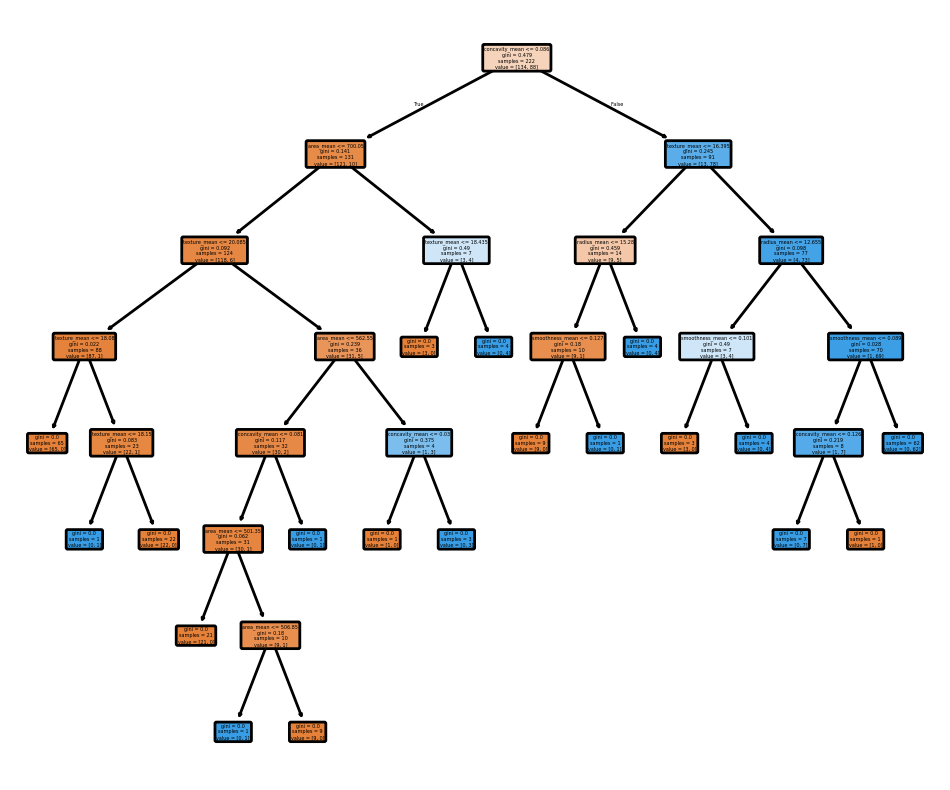

In [197]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,10))
plot_tree(dt, feature_names=X.columns, filled=True, rounded=True)
plt.show()

<p>
    The decision tree made a clear hierarchy, splitting on the most important features at each level. Gini impurity dropped as you go down, and some leaf nodes were perfectly pure (gini = 0.00). This shows the model learned useful rules from the data. But the deep branches also show it can overfit more easily than ensemble methods.
</p>

### 3.8.2 ROC curve

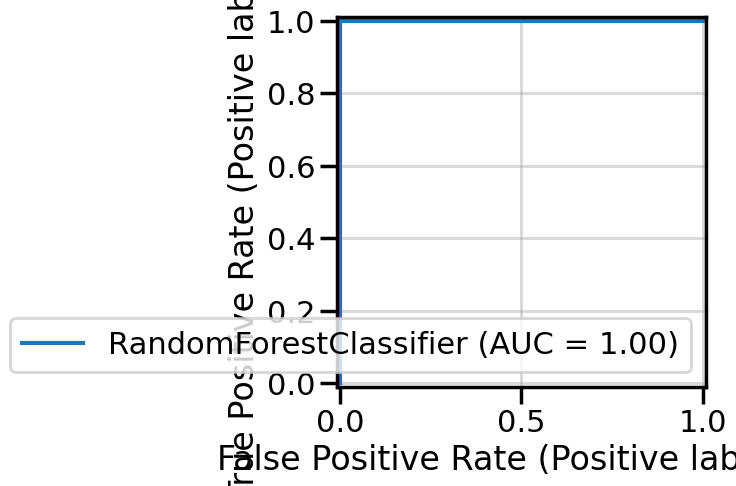

In [199]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
plt.grid(alpha=0.5)
plt.show()

<p>
    The ROC curve for the Random Forest classifier shows excellent performance, going quickly toward the top-left corner. This means the model has a very high true-positive rate while keeping the false-positive rate low. The AUC is 1.00, showing perfect separation between the two classes on the test data. This suggests Random Forest is very good at telling benign and malignant cases apart in this dataset.
</p>

# Section 4 : Workflow Explanation, Reflections, and Conclusions

## Introduction

<p>
This notebook shows the full machine learning process using the Breast Cancer dataset. The goal was to understand the data first. Then prepare it in the right way. After that, apply some transformations and do clustering. Finally, test classification models. Each step was done one by one. I used charts, basic statistics, and model results to help make decisions.

 The workflow includes exploratory data analysis, feature preprocessing, dimensionality reduction using PCA, clustering analysis, and supervised learning. Each step helped to understand the data better. It also made sure the models were trained using the right and useful features.   
</p> 

## 4.1 Exploratory Data Analysis and Feature Understanding

<p>
The first step was to explore the dataset. I needed to understand the input variables and the target variable called diagnosis. The diagnosis shows if the tumour is malignant (M) or benign (B). I looked at some important variables like radius_mean, texture_mean, smoothness_mean, and area_mean. These help describe the tumour shape and size.

Histograms showed that many features, especially radius_mean and texture_mean, were right skewed. This means most tumours had smaller values. Only a few had very large values. Boxplots grouped by diagnosis showed clear differences. Malignant tumours usually had higher values. They also showed more variation. This means these features are useful to tell the difference between malignant and benign tumours.

The correlation matrix showed weak links between predictors like radius_mean, texture_mean, and smoothness_mean. This was good because low correlation means less multicollinearity. Each feature can give its own information to the model.    
</p>

## 4.2 Feature Transformation and Scaling

<p>
I applied a few transformations to make the features more balanced. I used log10, square-root, and Box-Cox to reduce skewness. These made the data look more normal. The Box-Cox worked best and gave the most even distributions.

I also scaled the features using MinMax scaling and standardisation. MinMax scaled the values between 0 and 1. Standardisation centred them around zero and set variance to one. The histograms showed that scaling changed the size of the numbers but kept the overall shape the same.

These preprocessing steps mattered because many machine learning models work better when the features are scaled right and closer to normal.
</p>

## 4.3 Dimensionality Reduction using PCA

<p>
I used Principal Component Analysis (PCA) to make the dataset smaller but still keep the important information. The first two components explained about 78% of the variance, so most of the data was still there.

The PCA scatter plot showed that malignant and benign cases were partly separated. This meant the features had useful patterns. Making the data smaller also made clustering easier to see and faster to run.
</p>

## 4.4 Clustering Analysis

<p>
I tried three clustering methods: K-Means, Hierarchical Clustering, and DBSCAN. K-Means made clear groups and worked the best based on scores like silhouette, Davies-Bouldin, and Calinski-Harabasz.

The Elbow Method and Silhouette Analysis both said three clusters worked best. Hierarchical clustering also made sense, and the dendrogram showed natural groups. Cross-tables showed the clusters matched the diagnosis labels pretty well.

DBSCAN didn’t work. It marked almost everything as noise because the data wasn’t dense enough.

In the end, K-Means was the best fit for this dataset.
</p>

## 4.5 Supervised Learning and Model Evaluation

<p>
I trained and tested several classification models: K-Nearest Neighbours, Random Forest, Support Vector Machine, Logistic Regression, and Decision Tree. Cross-validation showed K-Nearest Neighbours had the highest accuracy at 93.28%.

Random Forest also did really well. It perfectly separated the test cases and got an AUC of 1.00. The ROC curve showed it classified cases very accurately. Decision Tree was easy to understand but seemed to overfit because it was too deep.

Overall, ensemble methods like Random Forest gave strong and stable results.
</p>

### Workflow Reflection

<p>
The workflow was done in a clear, step-by-step way:
	1.	Understand the dataset and how the features are spread out
	2.	Look at how the features relate to each other
	3.	Apply transformations and scale the data
	4.	Reduce dimensions using PCA
	5.	Run clustering methods
	6.	Train and test classification models

Each step had plots, tables, and some basic stats. This made the results more reliable and easier to understand.
</p>

### Strengths of the Workflow

<p>
	* The analysis was clear and easy to follow <br>
	* Preprocessing and scaling were done correctly <br>
	* PCA was used well to reduce dimensions <br>
	* Different clustering methods were compared <br>
	* Several classification models were tested <br>
	* Models performed well and the visuals were clear. <br>
</p>

### Limitations

<p>
	* The dataset was pretty small, so results might not work for other data <br>
	* Some clustering methods, like DBSCAN, didn’t work well <br>
	* Tuning hyperparameters more could make models better <br>
	* The models weren’t tested on other datasets <br>
</p>

### Recommendations for Improvement

<p>
	* Use bigger datasets to make the models more reliable <br>
	* Tune hyperparameters with GridSearchCV <br>
	* Try other models like Gradient Boosting or Neural Networks <br>
	* Look at feature importance more closely <br>
	* Test the models on separate datasets for validation <br>
</p>

### Ethical Considerations

<p>
Machine learning in healthcare needs to be used carefully. Wrong predictions could cause a wrong diagnosis or delay treatment. These models should help doctors, not replace them.
	* Patient data must stay private and safe <br>
	* Models should be easy to understand <br>
	* Bias should be kept low to make fair predictions <br>
	* Humans should always oversee medical AI systems <br>
</p>

### Final Conclusion

<p>
This project showed the full machine learning process using the Breast Cancer dataset. Exploring the data helped find important features like radius_mean and texture_mean. Transformations and scaling made the data better. PCA kept most of the information while making the dataset smaller.

Clustering showed useful patterns, and the supervised models were very accurate. Random Forest and K-Nearest Neighbours worked the best.

Overall, the workflow was clear and effective. The visuals and stats supported the results. It shows that machine learning can tell malignant and benign tumours apart if the data is prepared well and the right models are used.
</p>